In [18]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to C:\Users\csm02\AppData\Local\Temp\pip-req-build-41e1r16k
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369631 sha256=a41b8b72c1130a6c7573670f0777c1c9552e933a2c33efce1b100ddc860b7098
  Stored in directory: C:\Users\csm02\AppData\Local\Temp\pip-ephem-wheel-cache-t7vv507s\wheels\35\3e\df\3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip

   ---------------------------------------- 2/2 [clip]



  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git 'C:\Users\csm02\AppData\Local\Temp\pip-req-build-41e1r16k'


Using device: cuda


Using cache found in C:\Users\csm02/.cache\torch\hub\facebookresearch_detr_main
C:\Users\csm02\AppData\Local\Temp\ipykernel_12976\2985317571.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab10', num_objects)


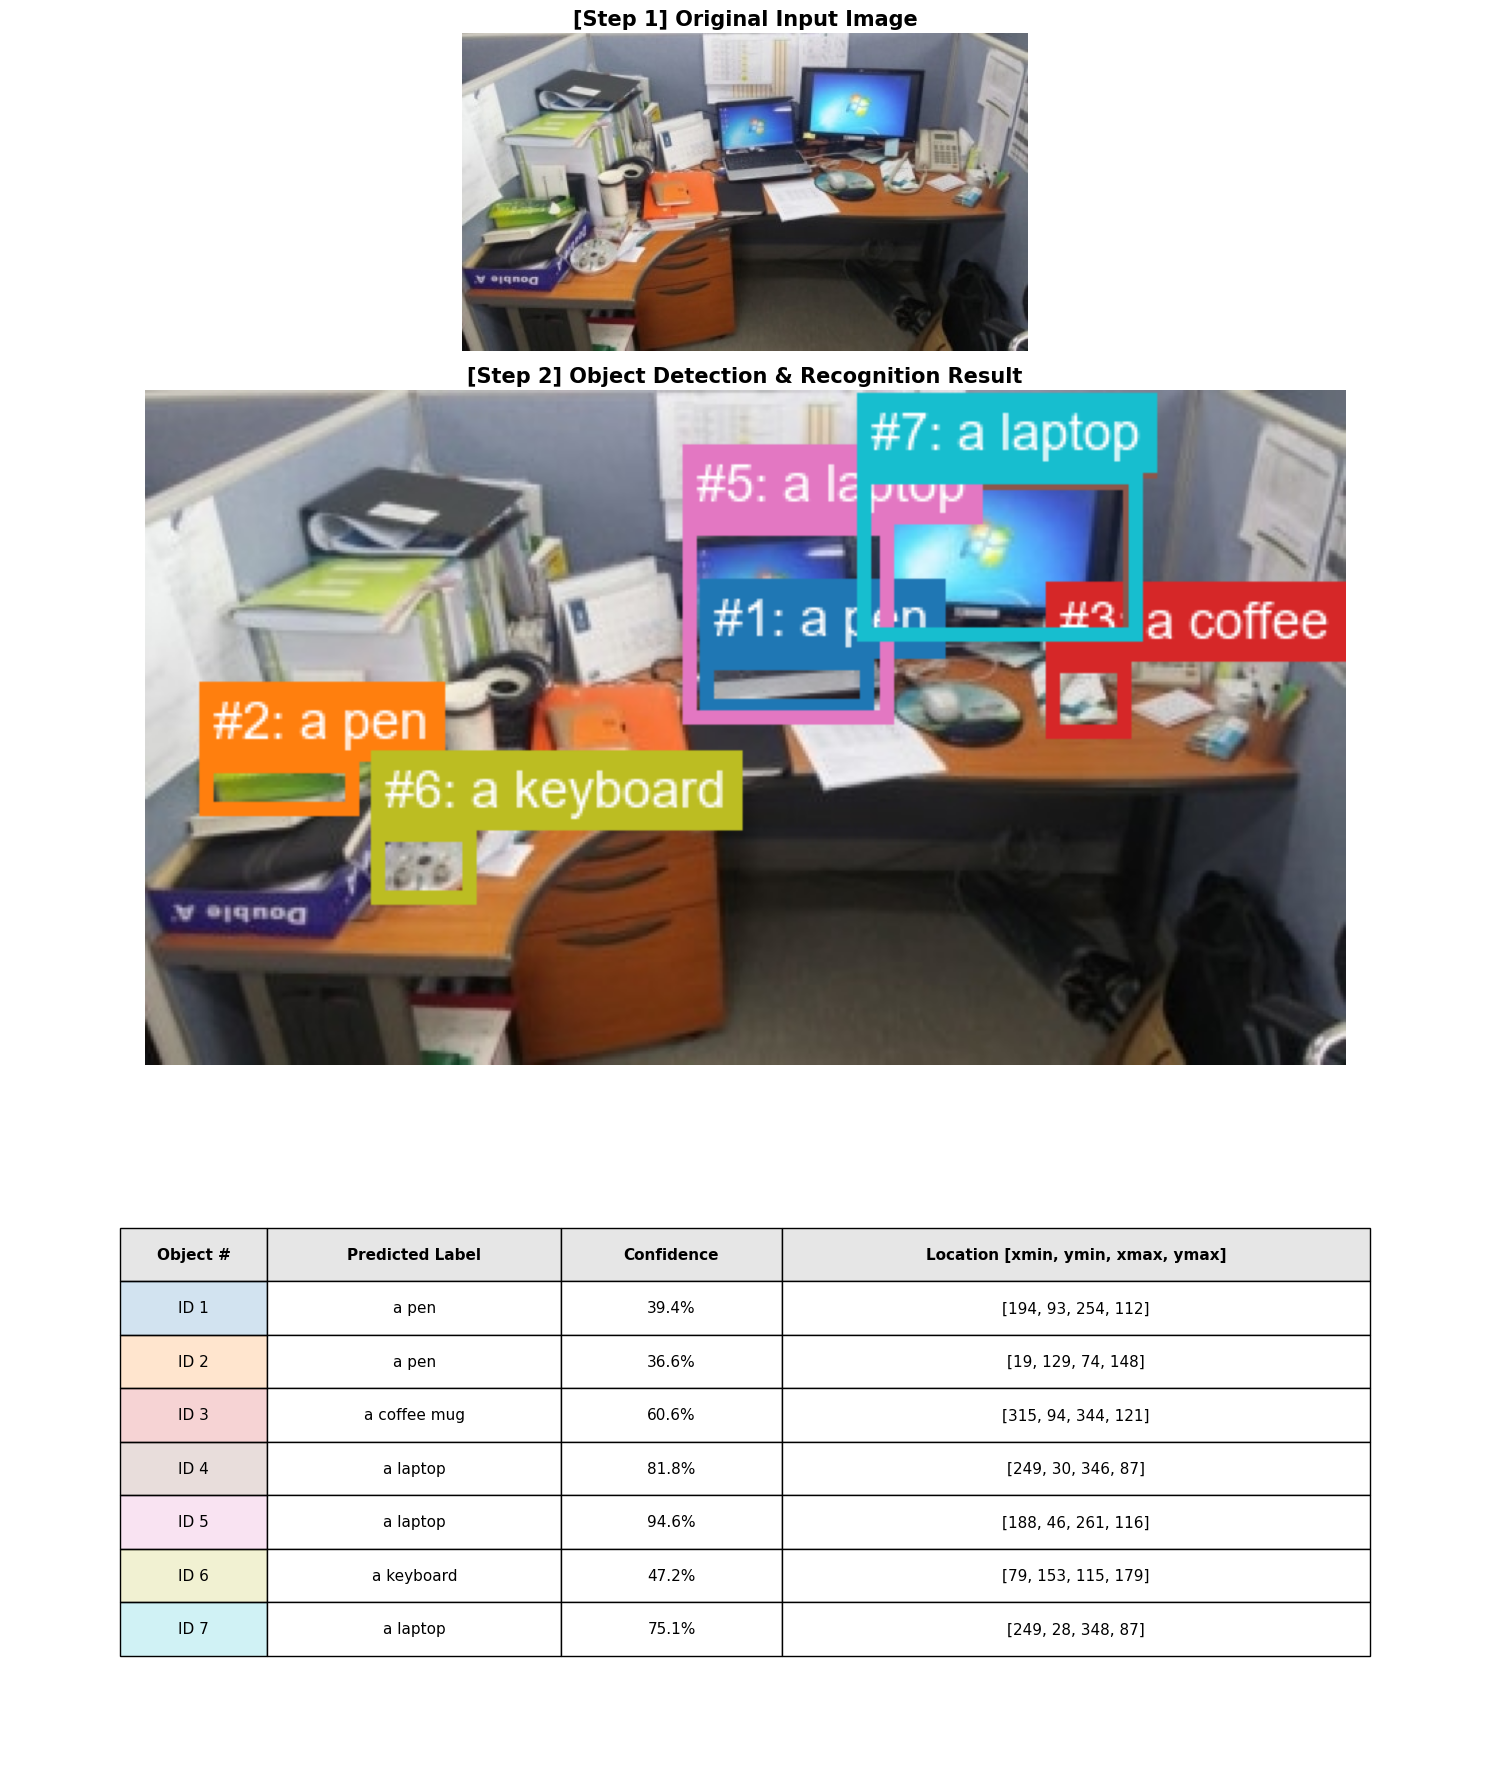

In [ ]:
import torch
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import clip
import os

# 1. model load
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

detr_model = torch.hub.load('facebookresearch/detr', 'detr_resnet50', pretrained=True).to(device)
detr_model.eval()

clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)

# 2. desktop image
image_path = "desk_item.jpg" 
if not os.path.exists(image_path):
    print(f"Error: 이미지 파일을 찾을 수 없습니다: {image_path}")
    exit()

original_image = Image.open(image_path).convert("RGB")
w, h = original_image.size
text_descriptions = ["a laptop", "a smartphone", "a book", "a coffee mug", "a pen", "a computer mouse", "a keyboard"]
text_tokens = clip.tokenize(text_descriptions).to(device)

# 3. DETR 객체 탐지
from torchvision.transforms import functional as F
detr_input = F.to_tensor(original_image).unsqueeze(0).to(device)
with torch.no_grad():
    detr_outputs = detr_model(detr_input)

probas = detr_outputs['pred_logits'].softmax(-1)[0, :, :-1]
keep = probas.max(-1).values > 0.7
boxes = detr_outputs['pred_boxes'][0, keep]

def box_cxcywh_to_xyxy(x):
    cx, cy, w, h = x.unbind(1)
    return torch.stack([(cx - 0.5 * w), (cy - 0.5 * h), (cx + 0.5 * w), (cy + 0.5 * h)], dim=1)

boxes_pixel = box_cxcywh_to_xyxy(boxes) * torch.tensor([w, h, w, h], dtype=torch.float32).to(device)

# 4. 객체별 분류 및 시각화 준비
draw_image = original_image.copy()
draw = ImageDraw.Draw(draw_image)
num_objects = len(boxes_pixel)
colormap = cm.get_cmap('tab10', num_objects)

results = []
try:
    font = ImageFont.truetype("arial.ttf", 18)
except:
    font = ImageFont.load_default()

for i, box in enumerate(boxes_pixel):
    color_rgb = tuple(int(c * 255) for c in colormap(i)[:3])
    xmin, ymin, xmax, ymax = map(int, box.tolist())
    xmin, ymin, xmax, ymax = max(0, xmin), max(0, ymin), min(w, xmax), min(h, ymax)
    
    # CLIP 분류
    cropped = original_image.crop((xmin, ymin, xmax, ymax))
    clip_input = clip_preprocess(cropped).unsqueeze(0).to(device)
    with torch.no_grad():
        logits, _ = clip_model(clip_input, text_tokens)
        probs = logits.softmax(dim=-1).cpu().numpy().squeeze()
    
    best_idx = np.argmax(probs)
    label = text_descriptions[best_idx]
    
    # 결과 저장 및 사진 드로잉
    results.append({'id': i+1, 'label': label, 'score': probs[best_idx], 'box': [xmin, ymin, xmax, ymax], 'color': color_rgb})
    
    draw.rectangle([xmin, ymin, xmax, ymax], outline=color_rgb, width=5)
    label_txt = f"#{i+1}: {label}"
    left, top, right, bottom = draw.textbbox((xmin, ymin), label_txt, font=font)
    draw.rectangle([xmin, ymin - (bottom-top) - 10, xmin + (right-left) + 10, ymin], fill=color_rgb)
    draw.text((xmin + 5, ymin - (bottom-top) - 7), label_txt, fill="white", font=font)

# 5. 최종 시각화 (원본 / 결과 / 테이블 3단 구성)
fig = plt.figure(figsize=(15, 18))
# 4행 1열 구조로 나누어 영역 할당
ax_orig = plt.subplot2grid((5, 1), (0, 0)) # 1행: 원본
ax_proc = plt.subplot2grid((5, 1), (1, 0), rowspan=2) # 2~3행: 결과 이미지
ax_table = plt.subplot2grid((5, 1), (3, 0), rowspan=2) # 4~5행: 테이블

# (1) 최상단: 원본 이미지
ax_orig.imshow(original_image)
ax_orig.set_title("[Step 1] Original Input Image", fontsize=15, fontweight='bold')
ax_orig.axis('off')

# (2) 중간: 결과 이미지 (테두리 + 라벨)
ax_proc.imshow(draw_image)
ax_proc.set_title("[Step 2] Object Detection & Recognition Result", fontsize=15, fontweight='bold')
ax_proc.axis('off')

# (3) 최하단: 테이블
ax_table.axis('off')
if results:
    table_data = [["Object #", "Predicted Label", "Confidence", "Location [xmin, ymin, xmax, ymax]"]]
    for res in results:
        table_data.append([f"ID {res['id']}", res['label'], f"{res['score']:.1%}", str(res['box'])])
    
    table = ax_table.table(cellText=table_data, loc='center', cellLoc='center', colWidths=[0.1, 0.2, 0.15, 0.4])
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.0, 2.5)
    
    # 스타일링
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#e6e6e6')
        elif col == 0 and row > 0:
            row_color = np.array(results[row-1]['color']) / 255.0
            cell.set_facecolor(list(row_color) + [0.2]) # 배경 투명도 0.2
else:
    ax_table.text(0.5, 0.5, "No objects detected.", ha='center', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn

# [Step 1] 모델 아키텍처 구성
# hub를 통해 구조를 가져오거나 직접 클래스를 정의합니다.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
model = torch.hub.load('facebookresearch/detr', 'detr_resnet50', pretrained=True)
model.to(device)

# [Step 2] 모델 파라미터 조절 (Fine-tuning 준비)
# 만약 특정 클래스(예: 책상 물건 5종)만 찾고 싶다면 출력 레이어를 수정합니다.
num_classes = 5 + 1 # 찾을 물건 5개 + 배경(Background)
model.class_embed = nn.Linear(256, num_classes).to(device)

# [Step 3] 가중치 저장 (.pth 파일 생성)
# 학습이 완료되었다고 가정하고 가중치를 저장합니다.
model_save_path = "my_custom_detr.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'num_classes': num_classes,
    'backbone': 'resnet50'
}, model_save_path)

print(f"모델이 {model_save_path}에 저장되었습니다.")